<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (569, 32)

First 5 Rows:
         id diagnosis  Radius_mean  Texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         21.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  

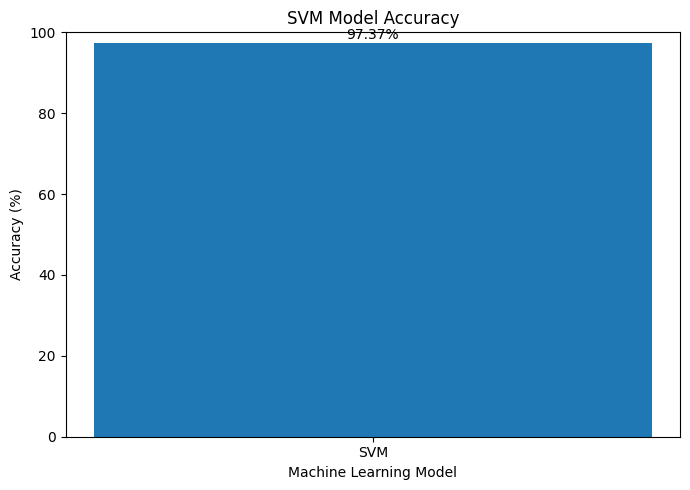

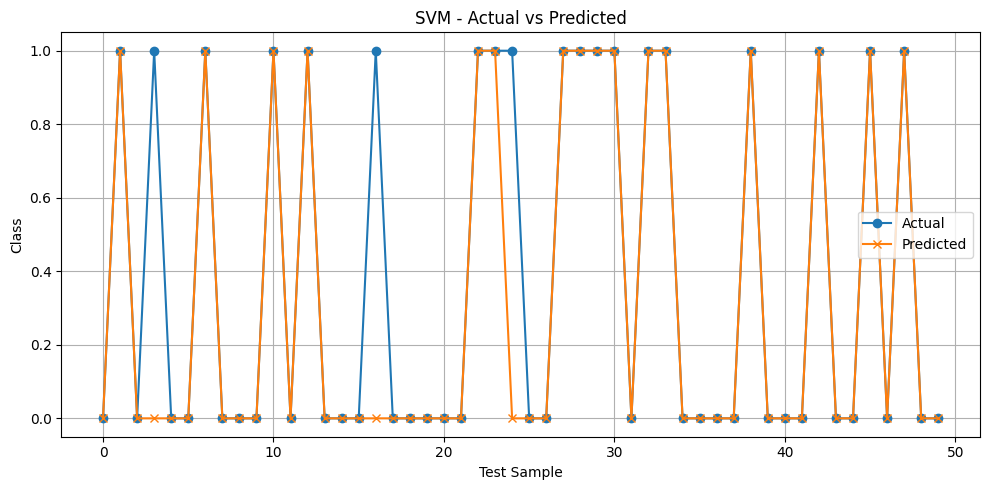

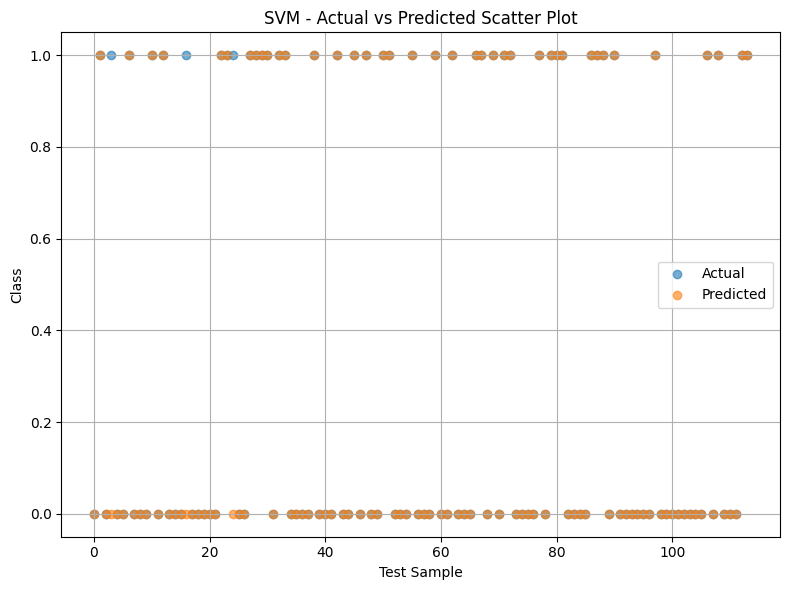

In [5]:
# ============================================================
# SVM CLASSIFICATION - BREAST CANCER DATASET
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("data.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()


# ============================================================
# 3. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum().sum())


# ============================================================
# 4. REMOVE UNNECESSARY ID COLUMN
# ============================================================

if "id" in df.columns:
    df = df.drop("id", axis=1)


# ============================================================
# 5. ENCODE TARGET COLUMN
# ============================================================

# M = 1
# B = 0

df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})


# ============================================================
# 6. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]


# ============================================================
# 7. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ============================================================
# 8. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


# ============================================================
# 9. CREATE SVM MODEL
# ============================================================

model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)


# ============================================================
# 10. TRAIN MODEL
# ============================================================

model.fit(
    X_train_scaled,
    y_train
)


# ============================================================
# 11. PREDICTION
# ============================================================

y_pred = model.predict(
    X_test_scaled
)


# ============================================================
# 12. CALCULATE ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n====================================")
print("SVM MODEL ACCURACY")
print("====================================")

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 14. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)


# ============================================================
# 15. BAR CHART - ACCURACY
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    ["SVM"],
    [accuracy * 100]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.title(
    "SVM Model Accuracy"
)

plt.ylim(0, 100)

plt.text(
    0,
    accuracy * 100 + 1,
    f"{accuracy * 100:.2f}%",
    ha="center"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. LINE CHART - ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values[:50],
    marker="o",
    label="Actual"
)

plt.plot(
    y_pred[:50],
    marker="x",
    label="Predicted"
)

plt.xlabel("Test Sample")
plt.ylabel("Class")

plt.title(
    "SVM - Actual vs Predicted"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()


# ============================================================
# 17. SCATTER CHART
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    range(len(y_test)),
    y_test,
    label="Actual",
    alpha=0.6
)

plt.scatter(
    range(len(y_pred)),
    y_pred,
    label="Predicted",
    alpha=0.6
)

plt.xlabel("Test Sample")
plt.ylabel("Class")

plt.title(
    "SVM - Actual vs Predicted Scatter Plot"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()